<a href="https://colab.research.google.com/github/TomaszPasnikowski/ML_2026_homeworks/blob/main/LAB11_Homework.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Homework Assignment: Is a *queen* really just a *king*, minus a *man*, plus a *woman*?**

--------------



In class, we dealt with **embeddings** trained for **sentiment classification**. These embeddings are optimized to separate *positive* from *negative* expressions and **do not encode deeper semantic information**.

However, in modern natural language processing, there exist other embeddings — such as those from **BERT**, **word2vec**, or **GloVe** — that **do capture semantic structure**. These models are trained on large corpora, and their embeddings often allow for meaningful **vector arithmetic**, like the famous:

```
embedding("king") - embedding("man") + embedding("woman") ≈ embedding("queen")
```

This homework explores **semantic vector relationships** using such pretrained embeddings.

## **The Objective**

Your task is to:

1. Construct semantic classes of word pairs.
2. Visualize them using PCA.
3. Explore arithmetic operations in embedding space.

## **Tasks & Deliverables**

### 1. **Semantic Pair Classes**

- You must gather **at least 10 classes** of semantically related word pairs.
- Each class must contain **at least 5 pairs**.
- That gives a **minimum total of 100 unique words** (10 classes x 5 pairs x 2 words per pair).

Two example classes:

**Class 1: Gender**

- (king, queen)
- (man, woman)
- (doctor, nurse)
- (prince, princess)
- *(you must add one more)*

**Class 2: Verb tense (past tense)**

- (bring, brought)
- (get, got)
- (like, liked)
- *(you must add two more)*

**Your job:**

- Invent or search for **at least 10 such classes**, including the examples above.
- Each class must be conceptually coherent.
- Other examples: singular/plural, country/capital, comparative/superlative, tool/user, job/object, etc.

### 2. **Global PCA (Across All Words)**

- Use PCA to reduce the **entire set of 100 word embeddings** to 2D, and plot it.
- Plot the additional **10 separate charts**, one for each class.
  - Each chart should display only the 10 words (5 pairs) of the given class.
- Points should be labeled with the words themselves.
- Use arrows to indicate matching pairs of points.

### 3. **Local PCA (Per Class)**

- For each class (10 total), perform PCA **only** on the 10 words of that class.
- Plot these class-wise PCA visualizations as separate charts.
- Again, points should be labeled with the words.
- Use arrows to indicate matching pairs of points.

**Total: 21 charts**
(1 global plot with 100 words + 10 global-space class plots + 10 local PCA class plots)

Charts should be presented in a self-explanatory manner with clear labels.

### 4. **Embedding Arithmetic**

For each class, choose **one example pair** (e.g., (king, queen)) and perform the operation:

```
embedding(B) - embedding(A) + embedding(C)
```

Where A and B form a known pair, and C is another base word.
For example:

```
embedding("king") - embedding("man") + embedding("woman")
```

* For each such result vector, find the **5 closest word embeddings** (using cosine similarity or Euclidean distance).
* Print the top 5 neighbors **with their distances**.
* Do this **once per class** (i.e., 10 times).

This will make it possible to verify if
 ```
embedding("queen") ≈ embedding("king") - embedding("man") + embedding("woman")
```
for the *gender*-related class.


### 5. **Discussion**

* Analyze and interpret your 21 plots.
* Discuss whether the vector relationships are preserved.
* Does PCA capture semantic differences?
* Are the closest words from the arithmetic meaningful?
* **Two very important points to include in the discussion:**
  1. What kinds of relationships are captured, and what are not?
  2. Are some classes better behaved than others?


In [1]:
!pip install gensim
import gensim.downloader as api
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

model = api.load("glove-wiki-gigaword-100")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 36.9 MB/s eta 0:00:00
[==================================================] 100.0% 128.1/128.1MB downloaded


## Setup

We will use the glove-wiki-gigaword-100 embeddings.

In [3]:
model = api.load("glove-wiki-gigaword-100")

def get_vec(w):
    if w not in model:
        raise KeyError(f"Word not in model: {w}")
    return model[w]

classes = {
    "Gender": [
        ("king", "queen"),
        ("man", "woman"),
        ("prince", "princess"),
        ("waiter", "waitress"),
        ("actor", "actress")
    ],

    "Verb Past Tense": [
        ("bring", "brought"),
        ("get", "got"),
        ("run", "ran"),
        ("eat", "ate"),
        ("write", "wrote")
    ],

    "Singular-Plural": [
        ("boat", "boats"),
        ("person", "people"),
        ("mouse", "mice"),
        ("goose", "geese"),
        ("tooth", "teeth")
    ],

    "Country-Capital": [
        ("france", "paris"),
        ("germany", "berlin"),
        ("japan", "tokyo"),
        ("poland", "warsaw"),
        ("italy", "rome")
    ],

    "Fruit": [
        ("strawberry", "red"),
        ("banana", "yellow"),
        ("plum", "purple"),
        ("pear", "green"),
        ("blueberry", "blue")
    ],

    "Action-Object": [
        ("talk", "phone"),
        ("watch", "television"),
        ("read", "book"),
        ("drive", "car"),
        ("listen", "headphones")
    ],

    "Tool-User": [
        ("hammer", "carpenter"),
        ("scalpel", "surgeon"),
        ("pen", "writer"),
        ("camera", "photographer"),
        ("stethoscope", "doctor")
    ],

    "Animal-Sound": [
        ("dog", "bark"),
        ("cat", "meow"),
        ("cow", "moo"),
        ("lion", "roar"),
        ("sheep", "bleat")
    ],

    "Object-Material": [
        ("bottle", "glass"),
        ("ring", "gold"),
        ("table", "wood"),
        ("shirt", "cotton"),
        ("pan", "steel")
    ],

    "Supervisor": [
        ("boss", "employee"),
        ("teacher", "student"),
        ("parent", "child"),
        ("master", "apprentice"),
        ("coach", "player")
    ]
}

all_words = sorted({w for pairs in classes.values() for p in pairs for w in p})
X = np.vstack([get_vec(w) for w in all_words])
print(X.shape)

## Global PCA (across all pairs)

In [5]:
pca_global = PCA(n_components=2)
X_global = pca_global.fit_transform(X)
coords_global = {w: X_global[i] for i, w in enumerate(all_words)}

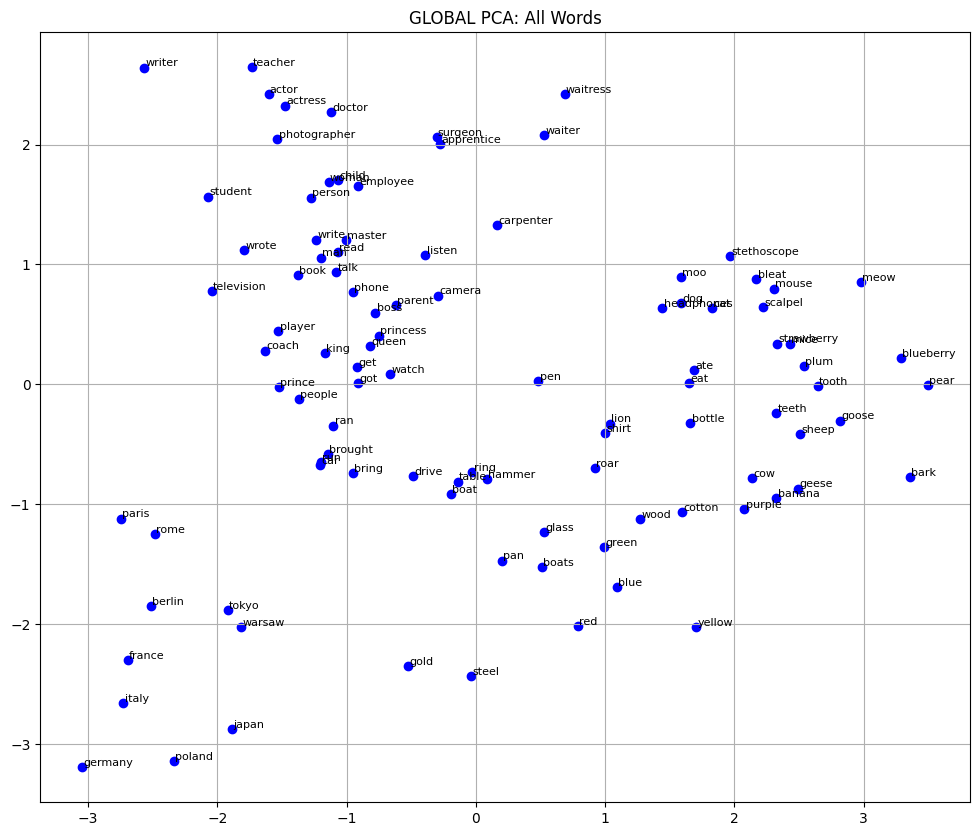

In [6]:
plt.figure(figsize=(12, 10))
for w, pt in coords_global.items():
    plt.scatter(pt[0], pt[1], c="blue")
    plt.text(pt[0]+0.01, pt[1]+0.01, w, fontsize=8)
plt.title("GLOBAL PCA: All Words")
plt.grid(True)
plt.show()

PCA across all the words captures some of the semantics. Many words form groups based on their meanings (for example, countries and cities are concentrated in one area) or are close to simmilar ones ("king", "queen" and "princess" are very close to each other). Some patterns are visible but there is also a lot of noise (for instance "purple" is much closer to "banana", than "yellow"). The imperfections may be a result of the glove 100 dimensional embedding being too weak to capture all the patterns or the 2-dim PCA method being to rough for this data.

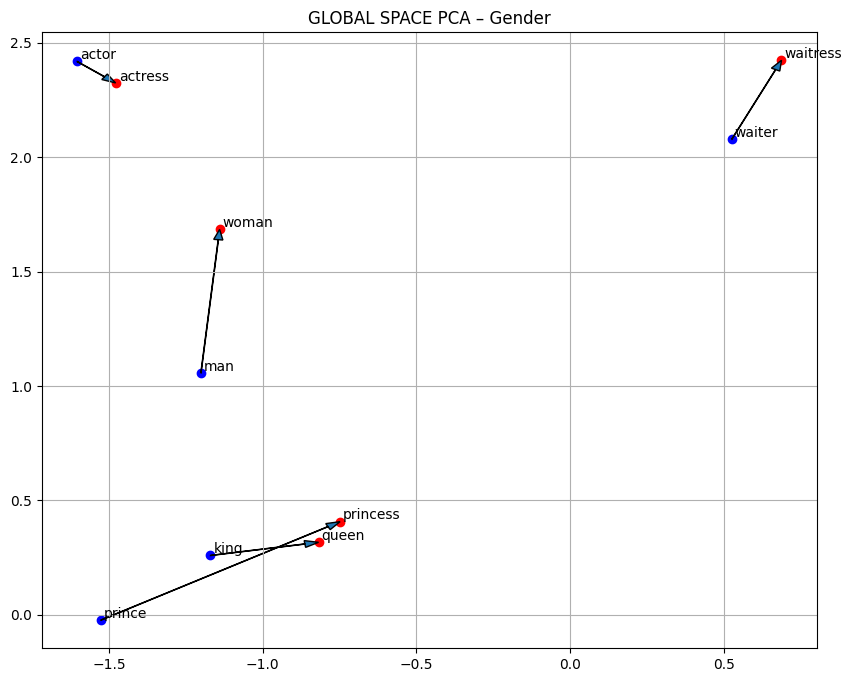

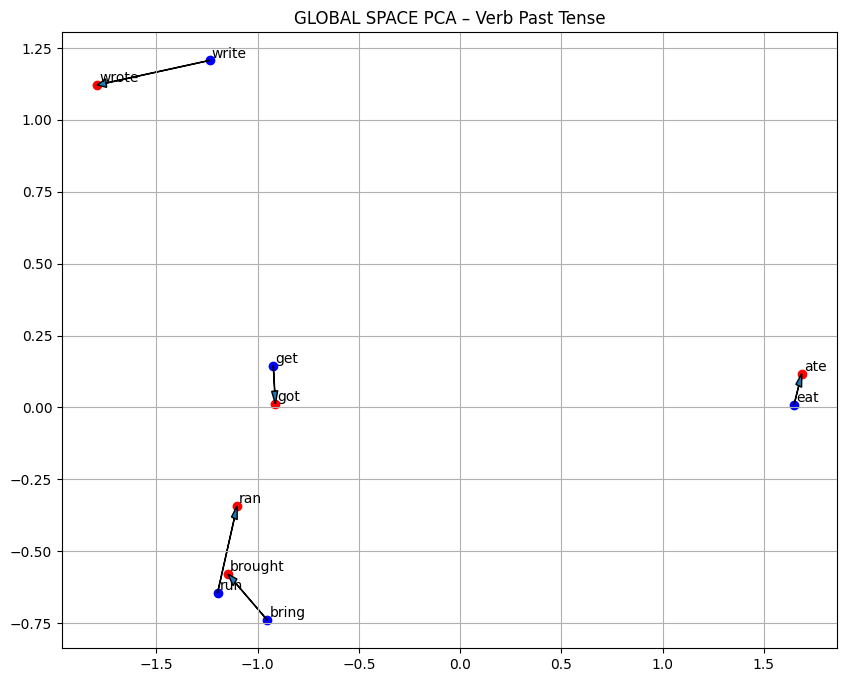

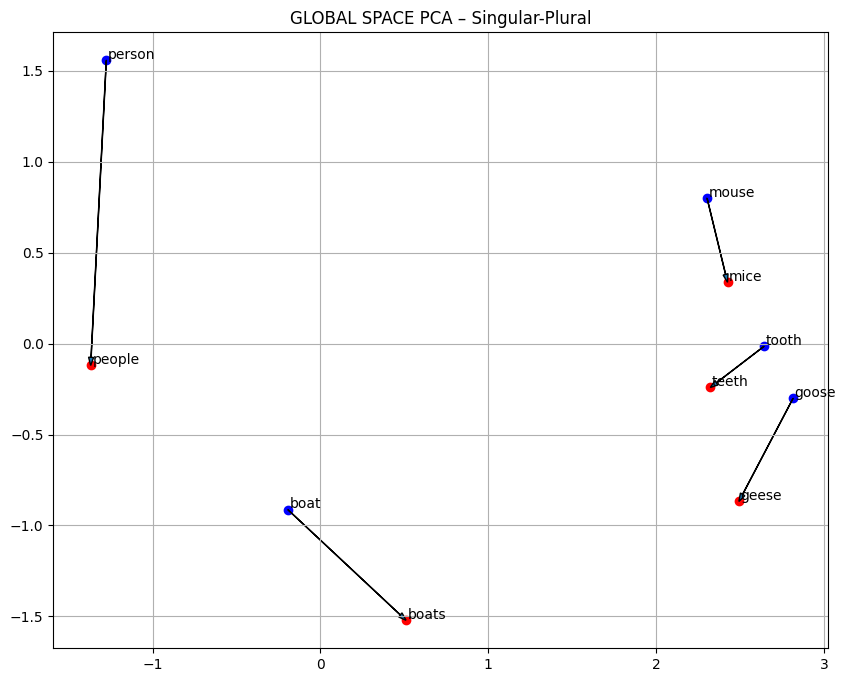

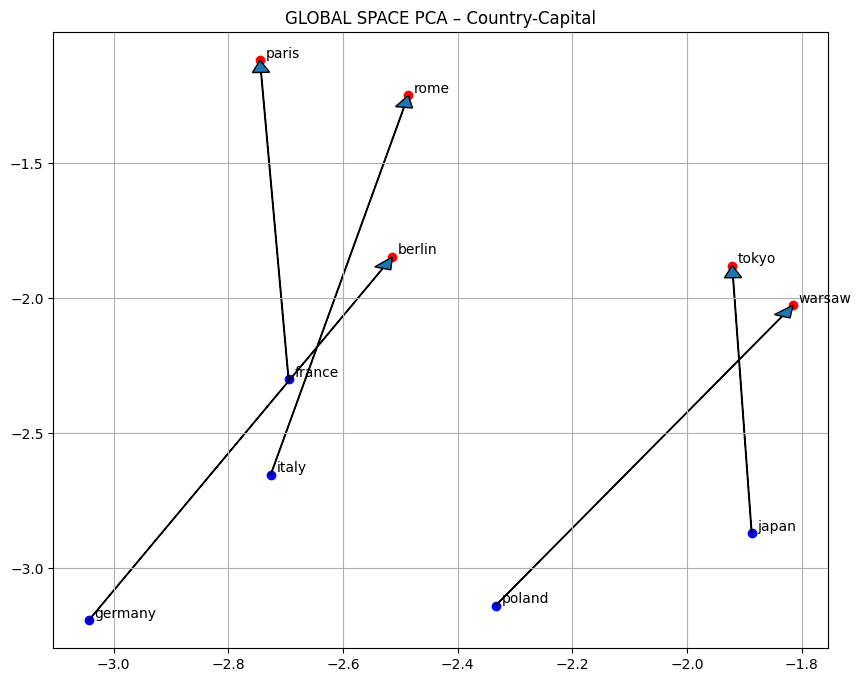

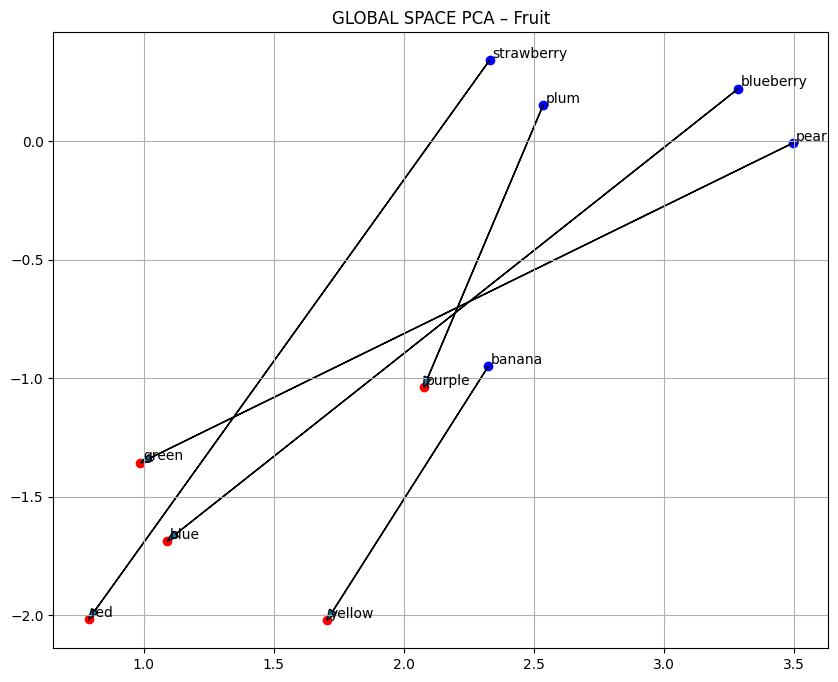

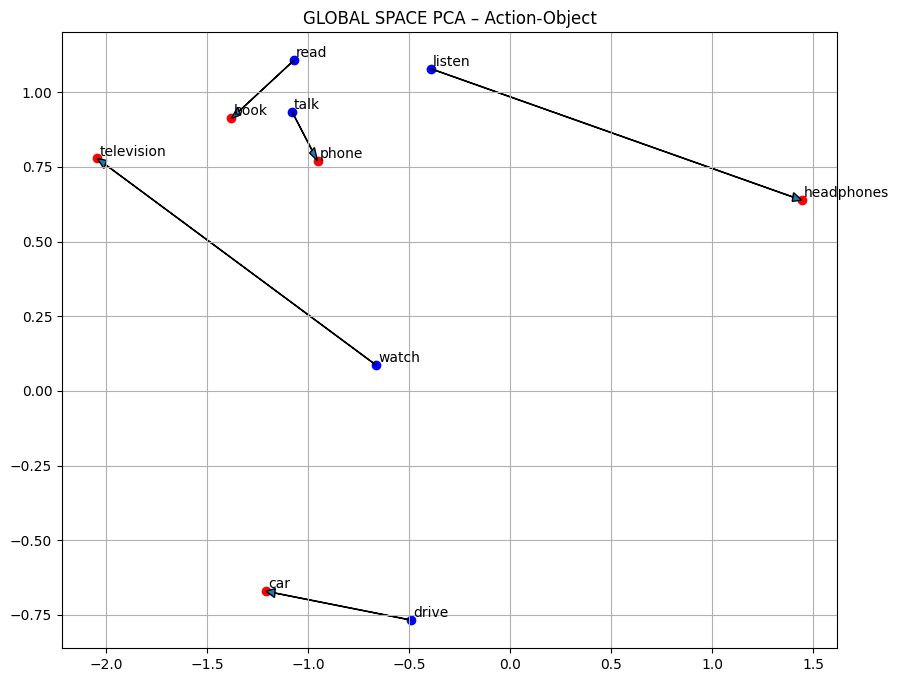

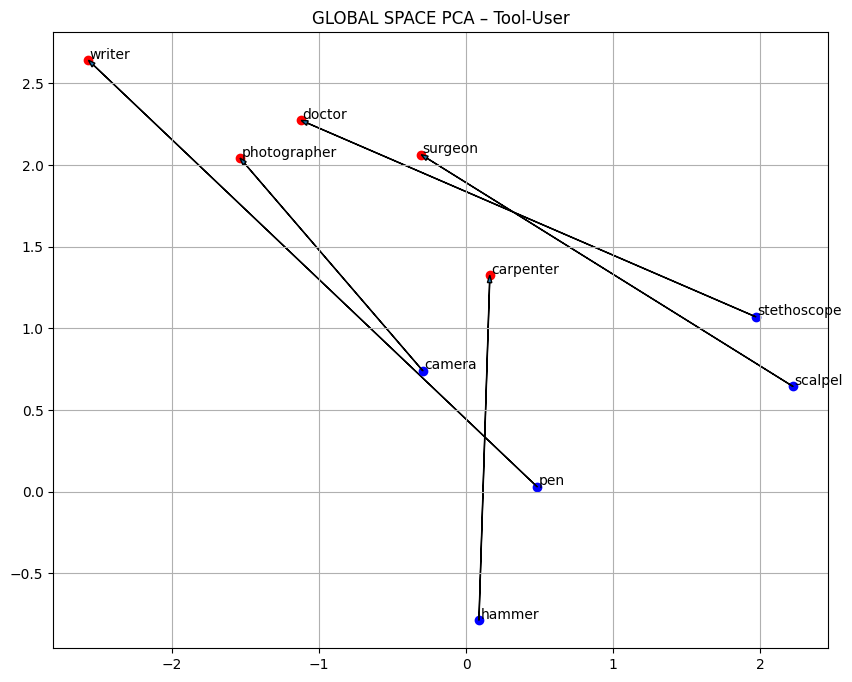

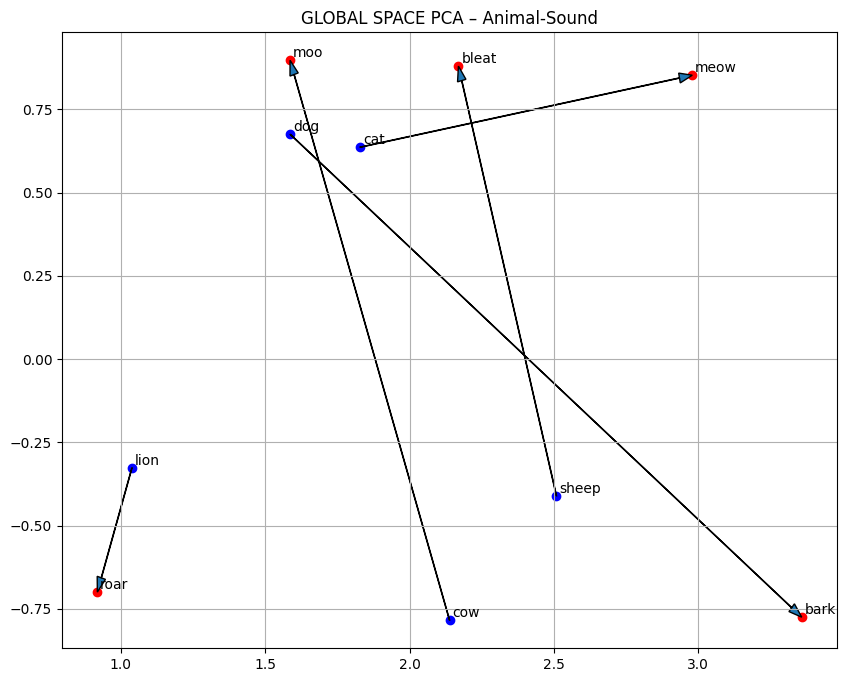

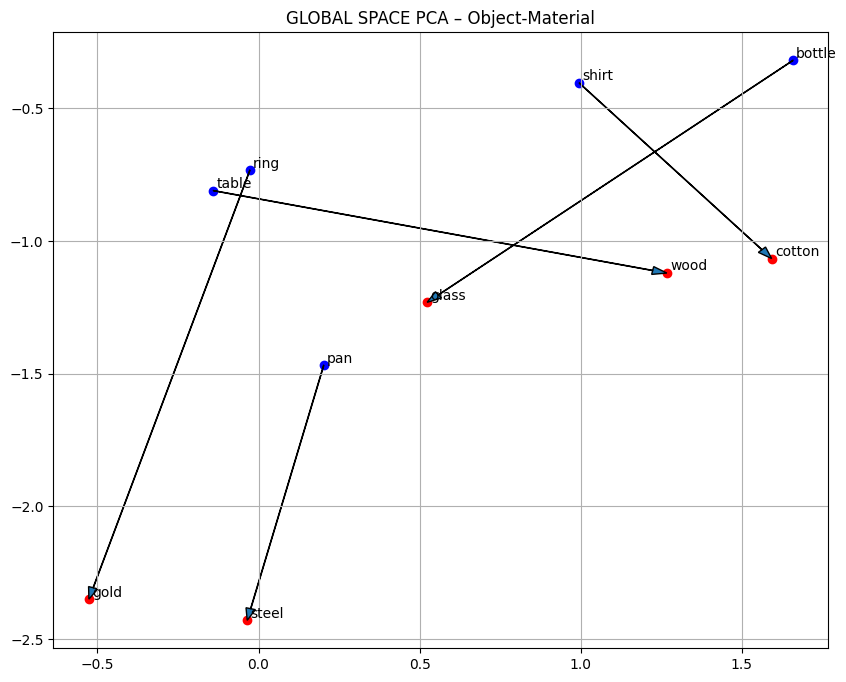

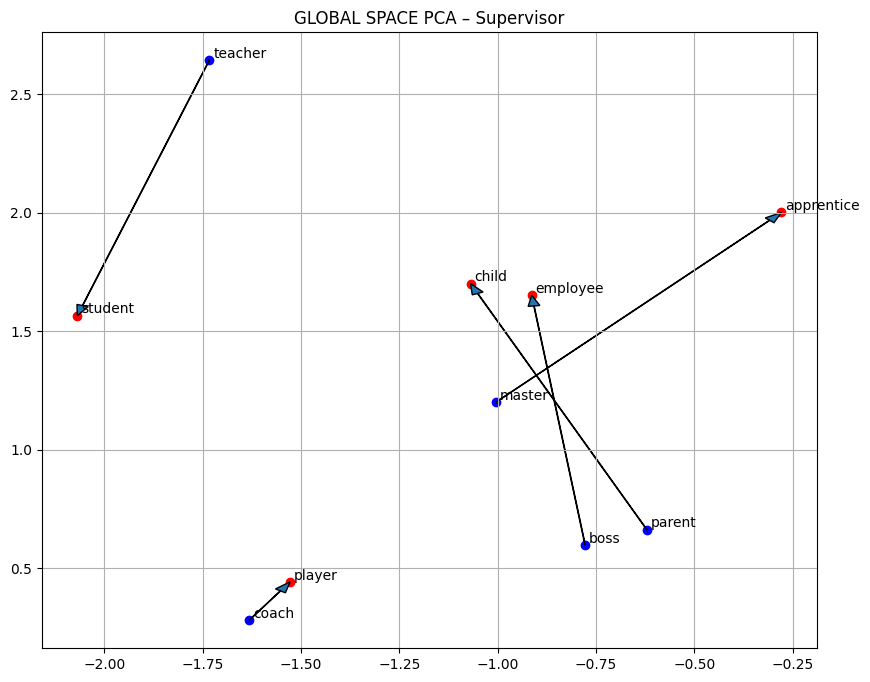

In [7]:
for cname, pairs in classes.items():
    plt.figure(figsize=(10, 8))
    for a, b in pairs:
        pa, pb = coords_global[a], coords_global[b]
        plt.scatter(pa[0], pa[1], c="blue")
        plt.scatter(pb[0], pb[1], c="red")
        plt.text(pa[0]+0.01, pa[1]+0.01, a)
        plt.text(pb[0]+0.01, pb[1]+0.01, b)
        plt.arrow(pa[0], pa[1], pb[0]-pa[0], pb[1]-pa[1],
                  length_includes_head=True, head_width=0.03)
    plt.title(f"GLOBAL SPACE PCA – {cname}")
    plt.grid(True)
    plt.show()

Most of the pairs do not have a consistant pattern within the global PCA. The arrows are usually in many directions and of various lengths. The pairs which seem to follow a consistant pattern the best are colors-fruit.

## Local PCA (within pairs)

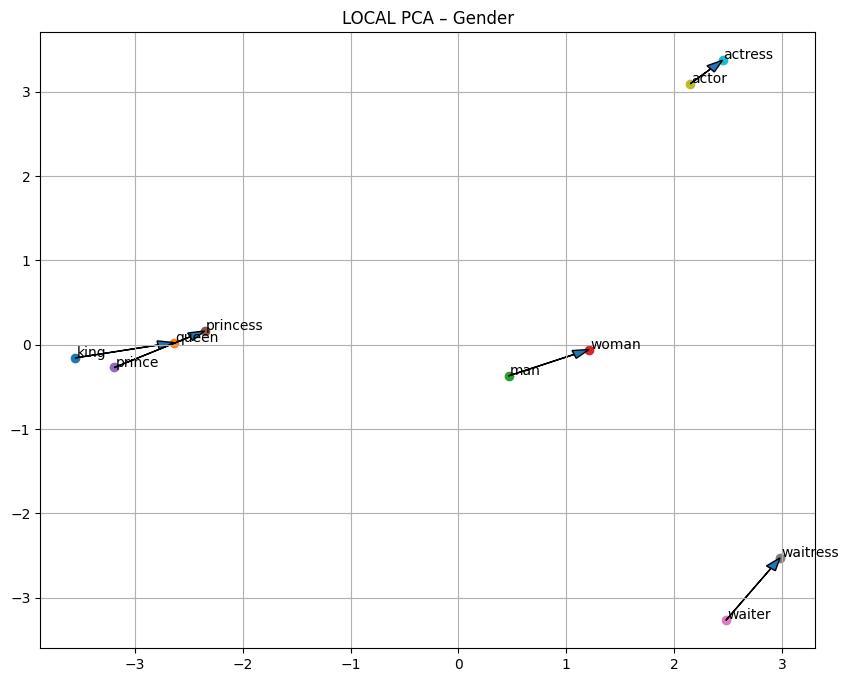

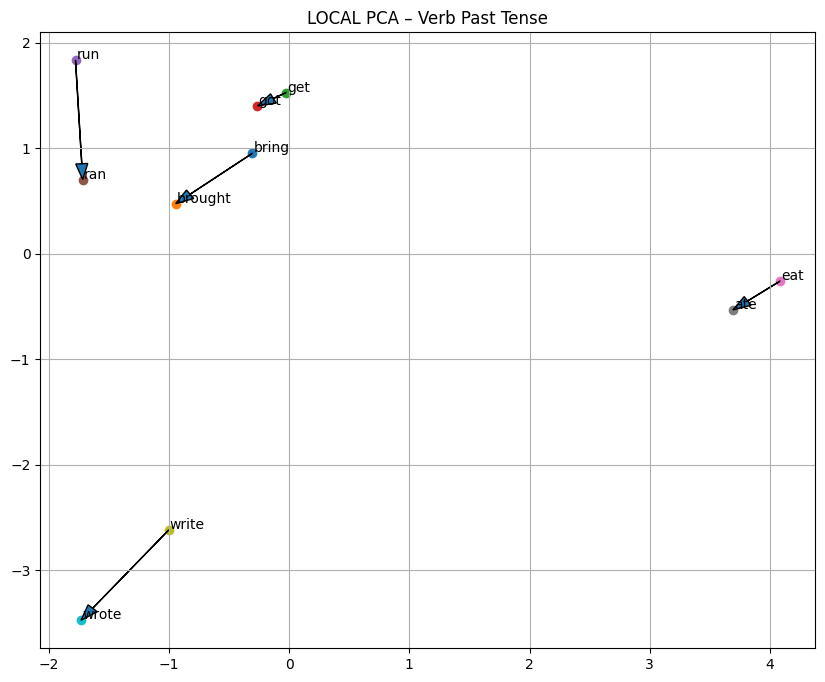

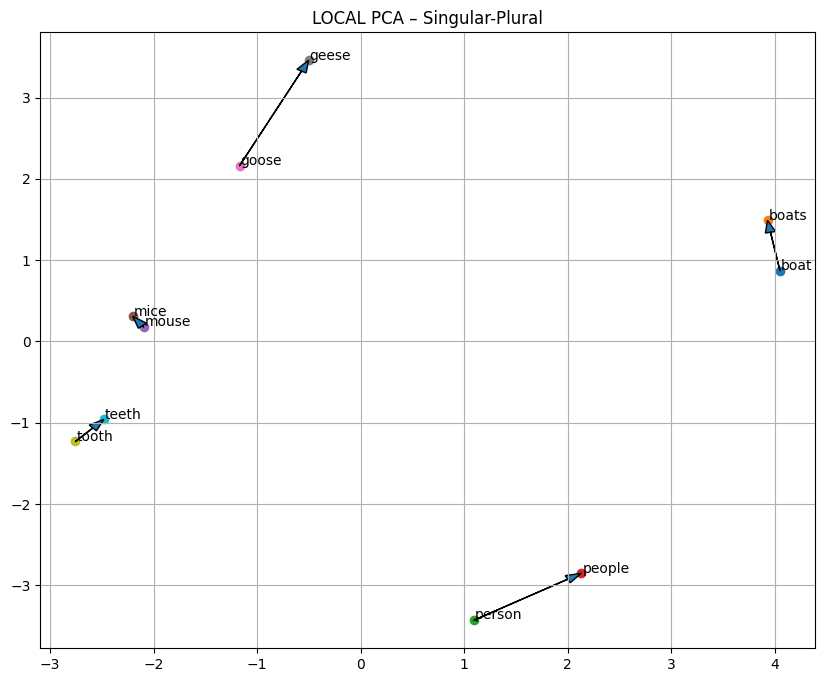

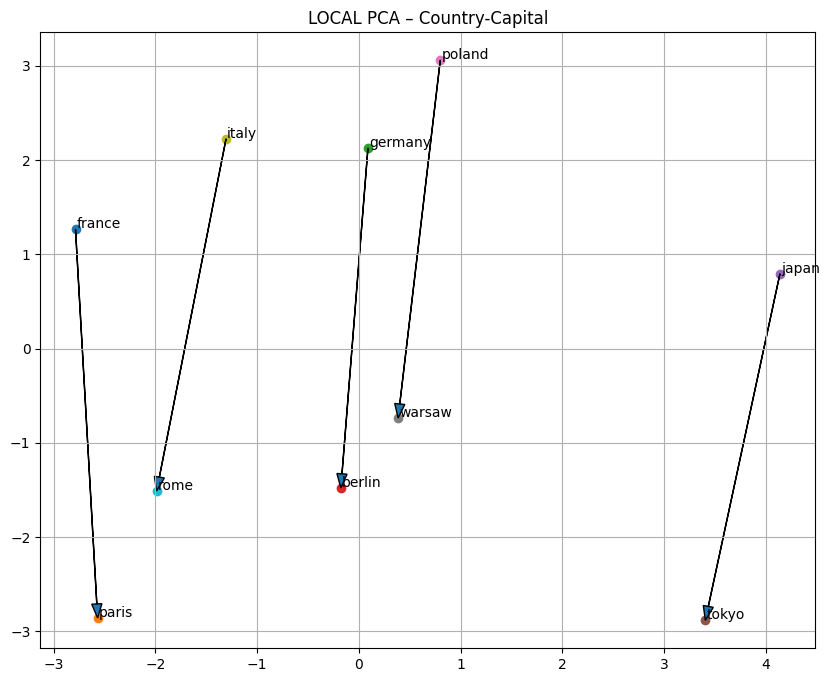

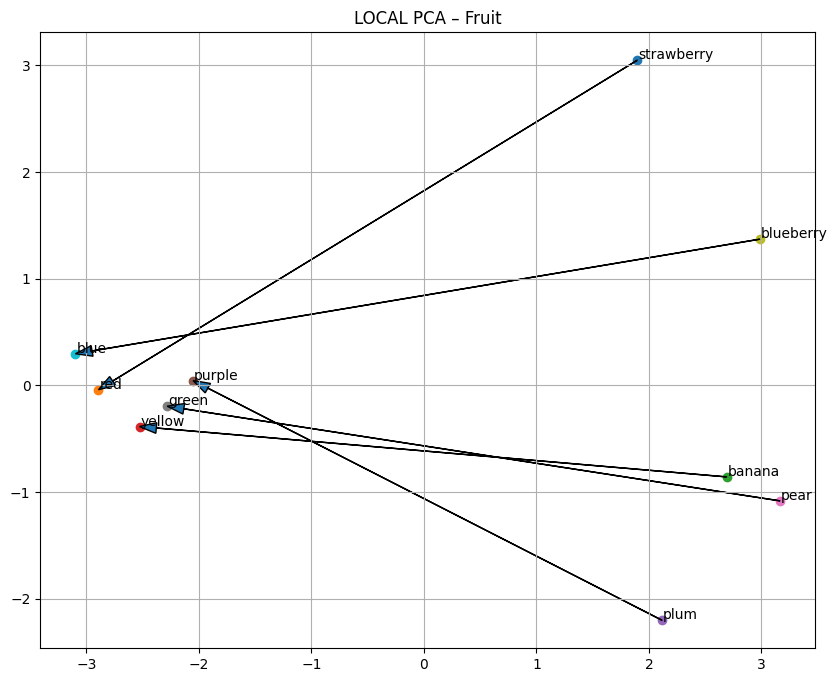

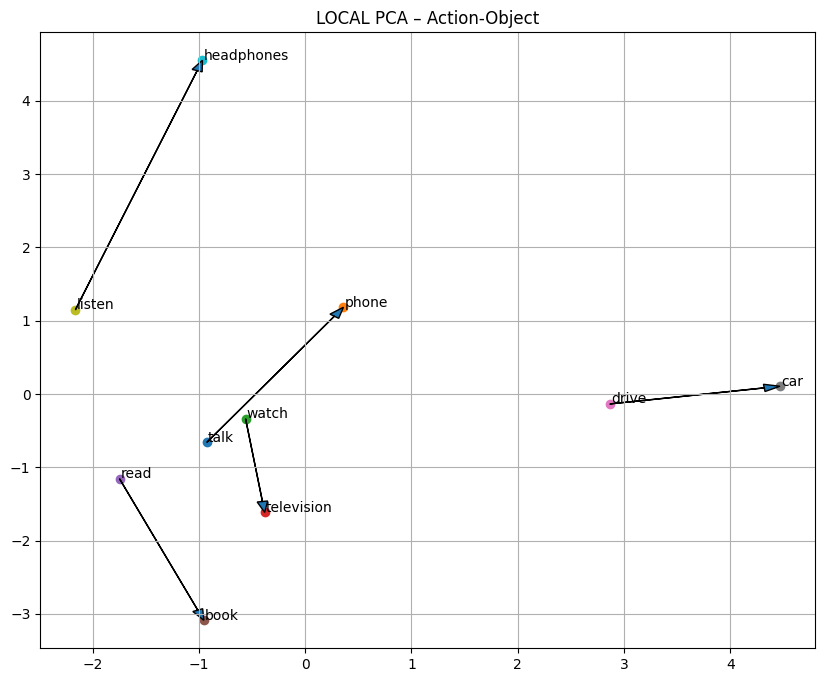

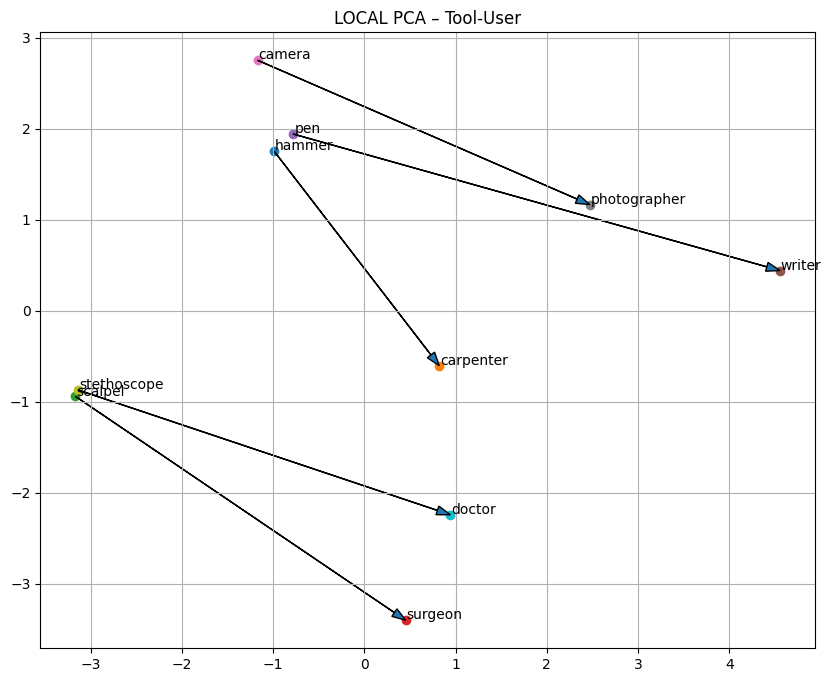

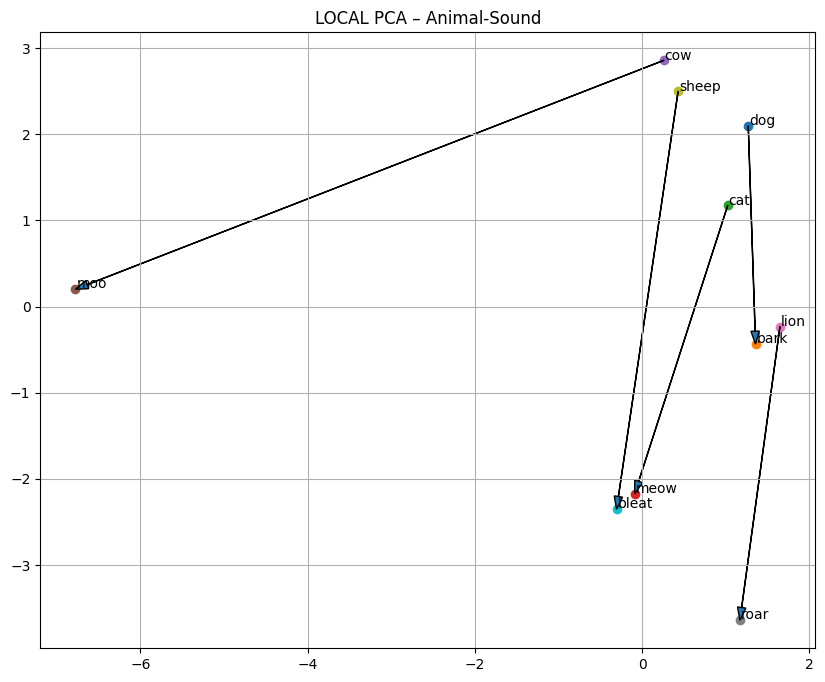

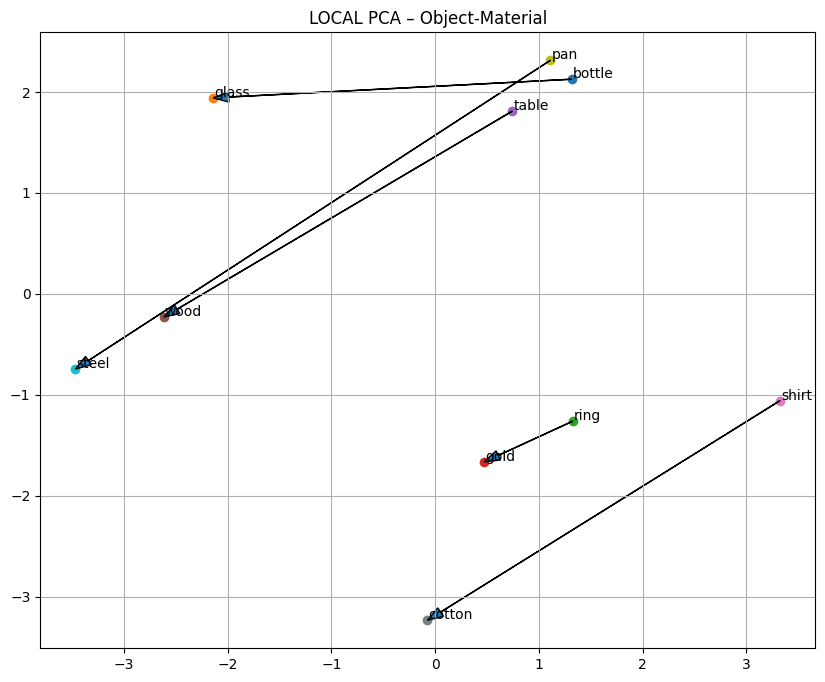

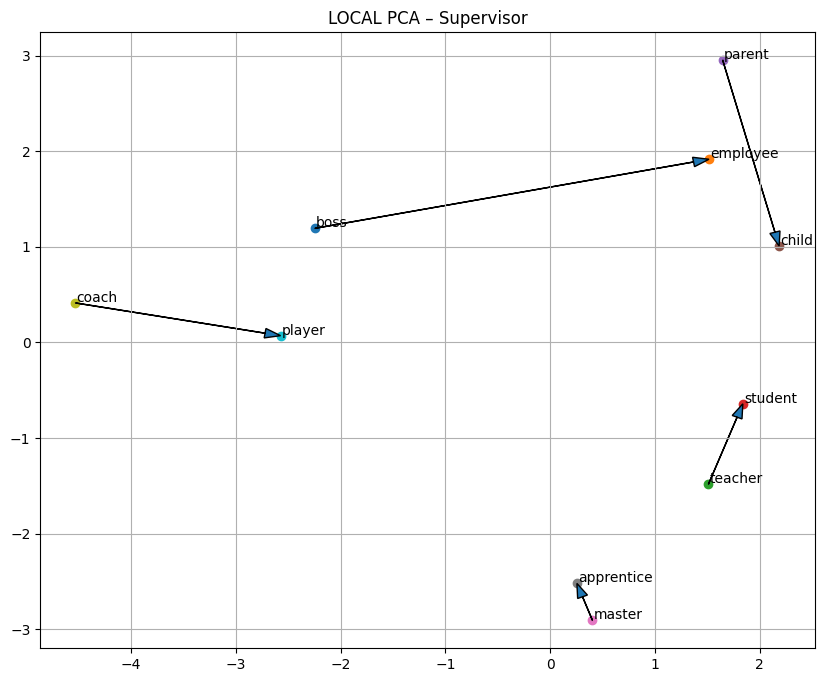

In [11]:
for cname, pairs in classes.items():
    words = [w for p in pairs for w in p]
    X_local = np.vstack([get_vec(w) for w in words])
    X2 = PCA(n_components=2).fit_transform(X_local)
    coords = {words[i]: X2[i] for i in range(len(words))}

    plt.figure(figsize=(10, 8))
    for a, b in pairs:
        pa, pb = coords[a], coords[b]
        plt.scatter(pa[0], pa[1])
        plt.scatter(pb[0], pb[1])
        plt.text(pa[0]+0.01, pa[1]+0.01, a)
        plt.text(pb[0]+0.01, pb[1]+0.01, b)
        plt.arrow(pa[0], pa[1], pb[0]-pa[0], pb[1]-pa[1],
                  length_includes_head=True, head_width=0.1)
    plt.title(f"LOCAL PCA – {cname}")
    plt.grid(True)
    plt.show()

The local principal components capture the semantic relations much better. The arrows are usually quite simmilar within pairs. The pairs with the best performances are gramatics-based words (past tenses, plural forms etc.) and pairs of countries and their capitals.

The worst performing classes are those that are based on a deeper meaning (for example, the analysis suggests that the embedding does not understand the resamblance between "parent"-"child" relation to the one of "boss"-"employee").

## Embedding arithmetic

In [12]:
def top_neighbors(vec, k=5):
    sims = model.cosine_similarities(vec, model[all_words])
    idx = np.argsort(-sims)[:k]
    return [(all_words[i], float(sims[i])) for i in idx]

for cname, pairs in classes.items():
    A, B = pairs[0]
    C, _ = pairs[1]

    vec = get_vec(B) - get_vec(A) + get_vec(C)
    neighbors = top_neighbors(vec)

    print(f"\nClass: {cname}")
    print(f"Operation: {B} - {A} + {C}")
    for w, s in neighbors:
        print(f"  {w:12s}  similarity={s:.4f}")


Class: Gender
Operation: queen - king + man
  woman         similarity=0.8040
  man           similarity=0.7791
  child         similarity=0.5974
  queen         similarity=0.5966
  person        similarity=0.5939

Class: Verb Past Tense
Operation: brought - bring + get
  got           similarity=0.9029
  get           similarity=0.8447
  brought       similarity=0.7803
  man           similarity=0.6655
  ran           similarity=0.6511

Class: Singular-Plural
Operation: boats - boat + person
  person        similarity=0.8501
  people        similarity=0.6930
  get           similarity=0.5723
  man           similarity=0.5496
  woman         similarity=0.5292

Class: Country-Capital
Operation: paris - france + germany
  berlin        similarity=0.8810
  germany       similarity=0.7425
  paris         similarity=0.7058
  tokyo         similarity=0.6613
  warsaw        similarity=0.6594

Class: Fruit
Operation: red - strawberry + banana
  red           similarity=0.7212
  yellow        

Many of the "arithmetic problems" are solved propely.
Classes that have the correct answer with the highest similarity:
  *   Gender
  *   Verb Past Tense
  *   Country-Capital

Some of the classes fail completely (like animal sounds where "bark" - "dog" + "cat" does not return a "meow" in the top 5).

The conclusions from the visual analysis are mostly confirmed - simple gramatics relations (maybe except Singular-Plural, where the correct answer came second) are well captured by the embedding as well as country-capital associations. Relations that require some deeper understanding of the words are too complex for this model.



